In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns;
import pandas as pd

In [71]:
mel_data = (
    pd.read_excel('Melbourne01.xlsx')
    .rename(columns=lambda col: col.strip())
)
mel_data.head()

,Year,Month,Day,Hour,Min,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Direction,Wind Speed (km/h),Wind Gust (km/h),MSLP (hPa),Rainfall since 9 am (mm),gamma,Calculated Dew Pt Temp (degrees C),E (hPa),Calculated Apparent Temp (degrees C)
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,SE,11,13.0,1007.4,0,0.969609,14.1,15.916676,23.9
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,SE,11,11.0,1007.5,0,0.908985,13.2,14.980401,23.6
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,SE,11,13.0,1007.5,0,0.915025,13.2,15.069879,23.7
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,SE,11,11.0,1007.4,0,0.923560,13.4,15.201624,23.6
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,ESE,9,9.0,1007.3,0,0.927209,13.4,15.264860,23.4


# Cleaning

In [72]:
(len(mel_data)-len(mel_data.dropna()))/len(mel_data)

0.0015335754073868865

In [73]:
mel_data = mel_data.dropna() # Drop none in raw data

In [74]:
numeric_cols = mel_data.columns.drop("Wind Direction")

mel_data[numeric_cols] = mel_data[numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)

mel_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504580 entries, 0 to 505354
Data columns (total 18 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Year                                  504580 non-null  int64  
 1   Month                                 504580 non-null  int64  
 2   Day                                   504580 non-null  float64
 3   Hour                                  504580 non-null  float64
 4   Min                                   504580 non-null  float64
 5   Air Temp (degrees C)                  504580 non-null  float64
 6   Apparent Temp (degrees C)             504580 non-null  float64
 7   Dew Pt Temp (degrees C)               504580 non-null  float64
 8   Humidity (%)                          504580 non-null  float64
 9   Wind Direction                        504580 non-null  object 
 10  Wind Speed (km/h)                     504580 non-null  int64  
 11  Wind 

In [75]:
(len(mel_data)-len(mel_data.dropna()))/len(mel_data)

0.0001585477030401522

In [76]:
mel_data = mel_data.dropna() # Drop none after converting to numeric, if there are any

In [77]:
mel_data.rename(columns={'Min': 'Minute'}, inplace=True)

mel_data['Datetime'] = pd.to_datetime(
    mel_data[['Year','Month','Day','Hour','Minute']]
)
mel_data.sort_values('Datetime', inplace=True)
mel_data.Datetime.head()

0   2011-01-01 00:04:00
1   2011-01-01 00:14:00
2   2011-01-01 00:24:00
3   2011-01-01 00:34:00
4   2011-01-01 00:44:00
Name: Datetime, dtype: datetime64[ns]

In [78]:
mel_data["Wind Direction"].unique()

array(['SE', 'ESE', 'NE', 'NNE', 'ENE', 'W', 'N', 'SW', 'SSE', 'S', 'SSW',
       'WSW', 'NW', 'WNW', 'NNW', 'E', 'CALM', 1016.6, 1016.9, 1017,
       1017.4, 1026, 1026.1, 1025.3, 1024.2, 1029.6, 1003.3, 1008.2, 1019,
       1015.5, 1014.2, 1015.9, 1016.2, 1016.1, 1014.1, 1014, 1013.6,
       1012.7, 1013.1, 1014.4, 1014.6, 1015.6, 1015.8, 1016.7, 1017.2,
       1016, 1017.8, 1019.5, 1019.8, 1019.9, 1020.4, 1021, 1021.2, 1021.7,
       1021.9, 1022.3, 1022.7, 1004.5, 1022, 1010.3, 1012, 1010.8, '-'],
      dtype=object)

In [79]:
invalid_float_count = mel_data["Wind Direction"].apply(lambda x: isinstance(x, float)).sum()
invalid_dash_count = (mel_data["Wind Direction"] == '-').sum()

print("Float values:", invalid_float_count)
print("Dash values:", invalid_dash_count)

Float values: 47
Dash values: 1


In [80]:
valid_wind_dirs = {
    'N','NNE','NE','ENE','E','ESE','SE','SSE','S',
    'SSW','SW','WSW','W','WNW','NW','NNW','CALM'
}

mel_data = mel_data[mel_data['Wind Direction'].isin(valid_wind_dirs)] # Keep only valid wind directions

In [81]:
mel_data.columns

Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Air Temp (degrees C)',
       'Apparent Temp (degrees C)', 'Dew Pt Temp (degrees C)', 'Humidity (%)',
       'Wind Direction', 'Wind Speed (km/h)', 'Wind Gust  (km/h)',
       'MSLP (hPa)', 'Rainfall since 9 am (mm)', 'gamma',
       'Calculated Dew Pt Temp (degrees C)', 'E (hPa)',
       'Calculated Apparent Temp (degrees C)', 'Datetime'],
      dtype='object')

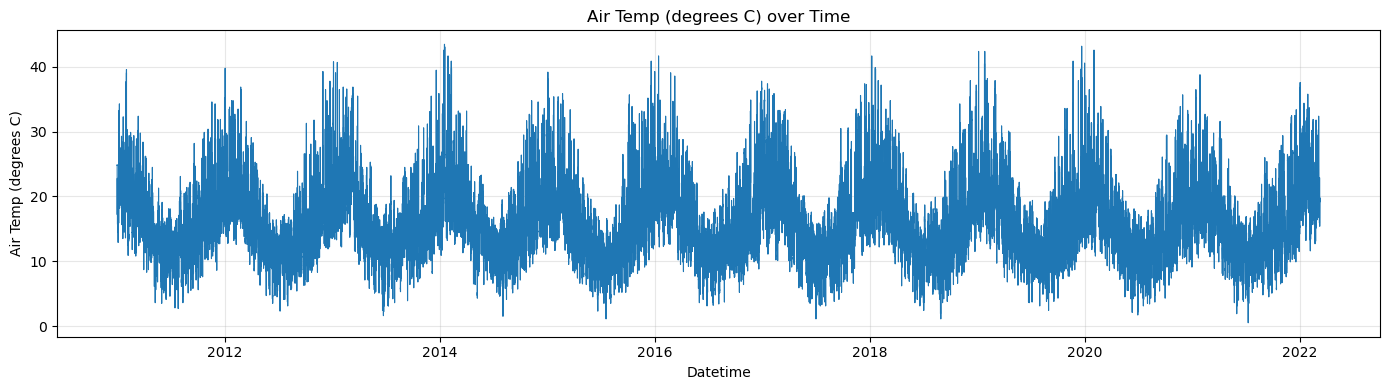

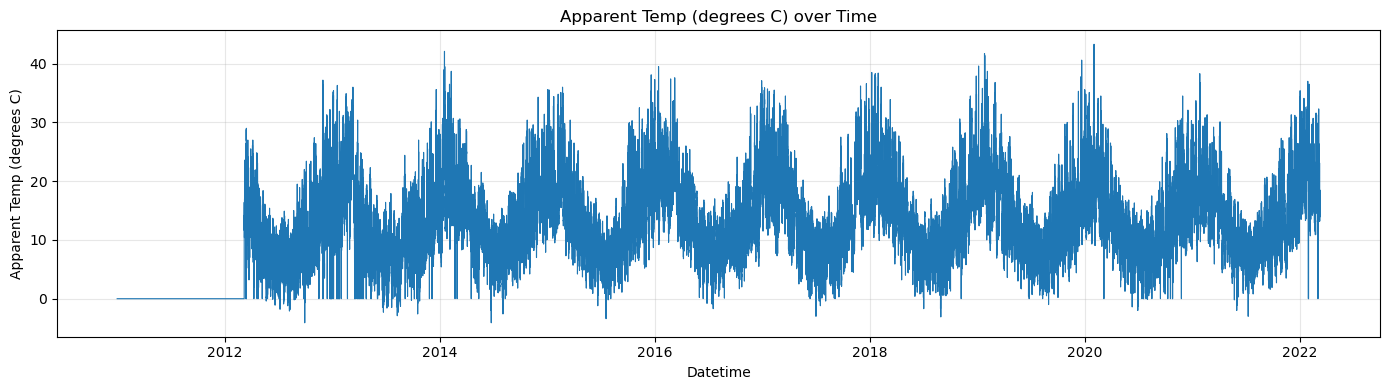

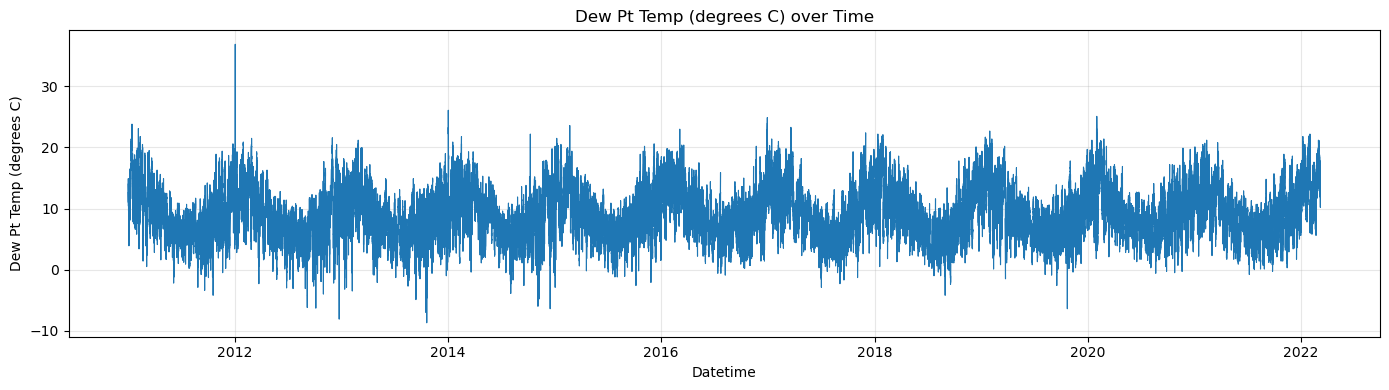

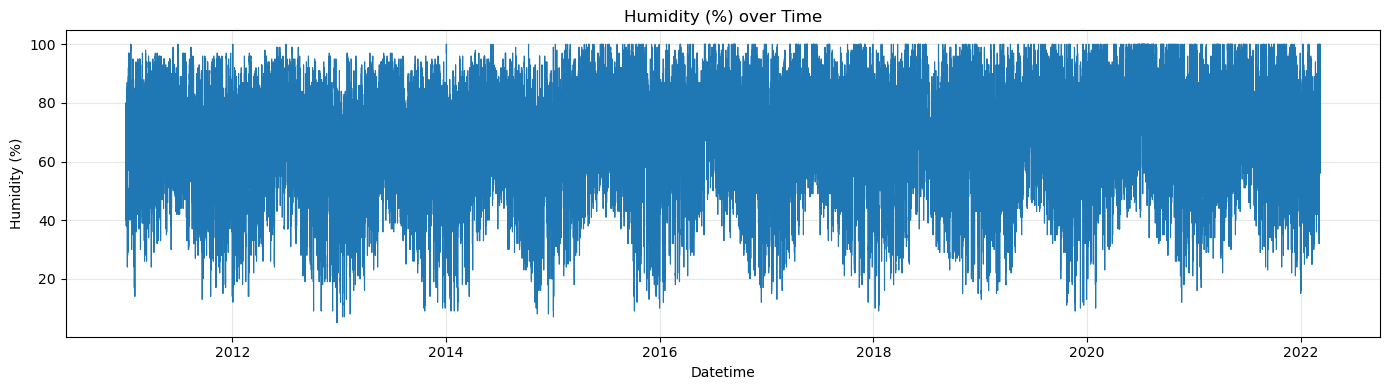

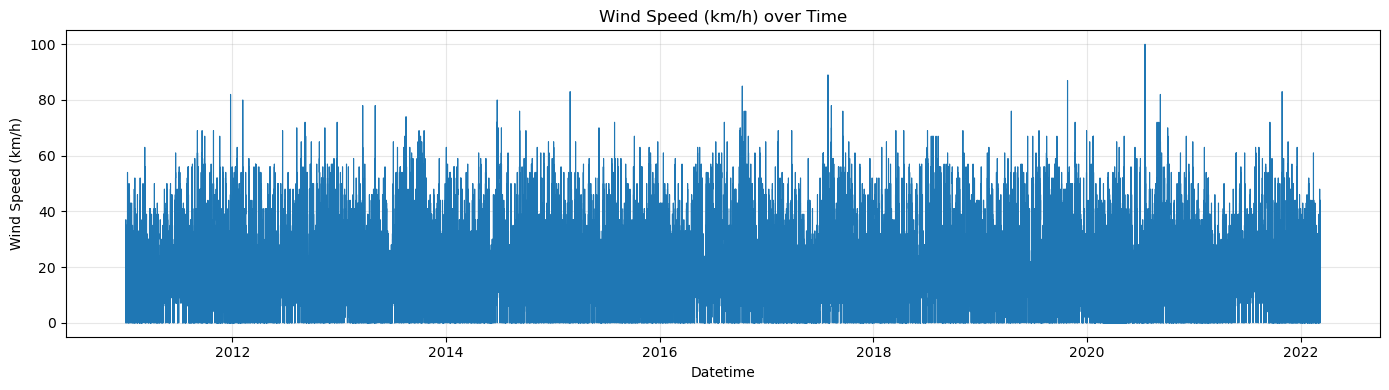

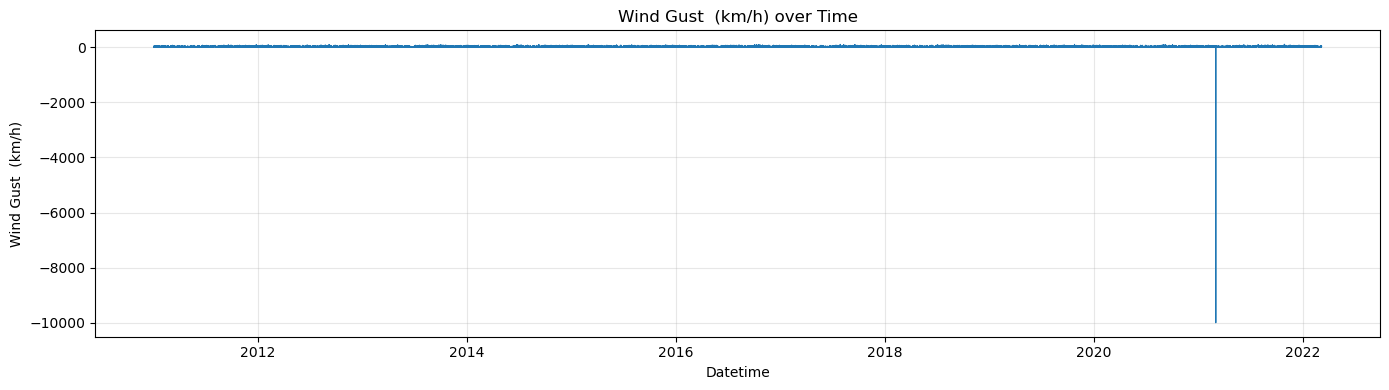

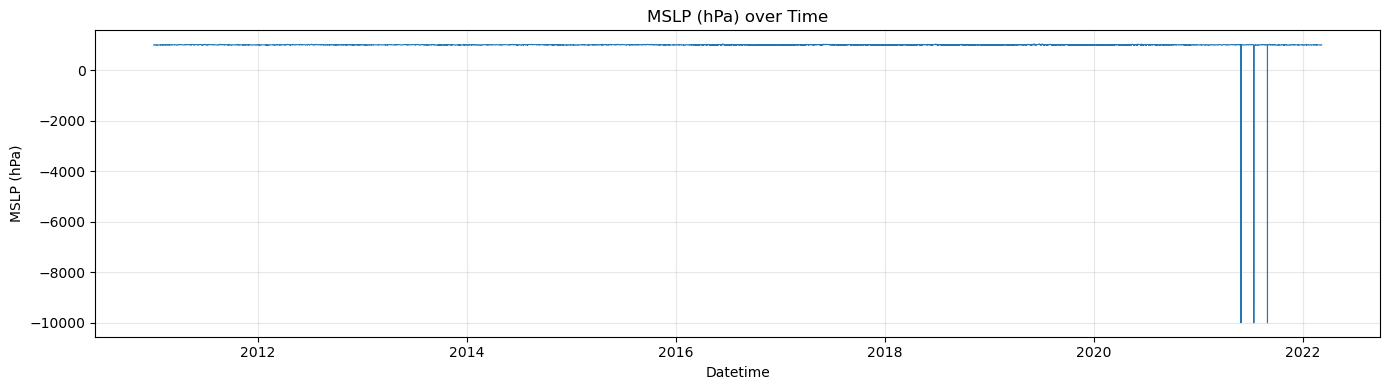

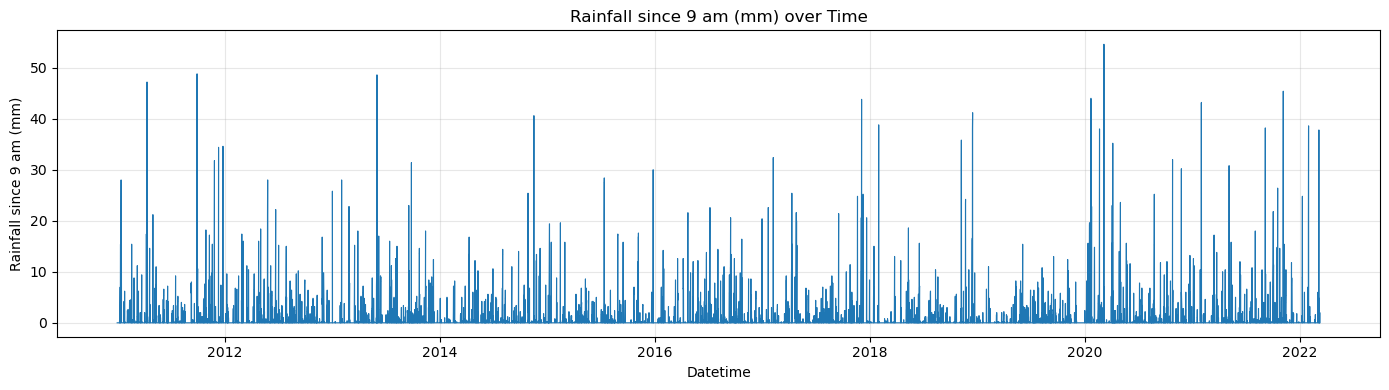

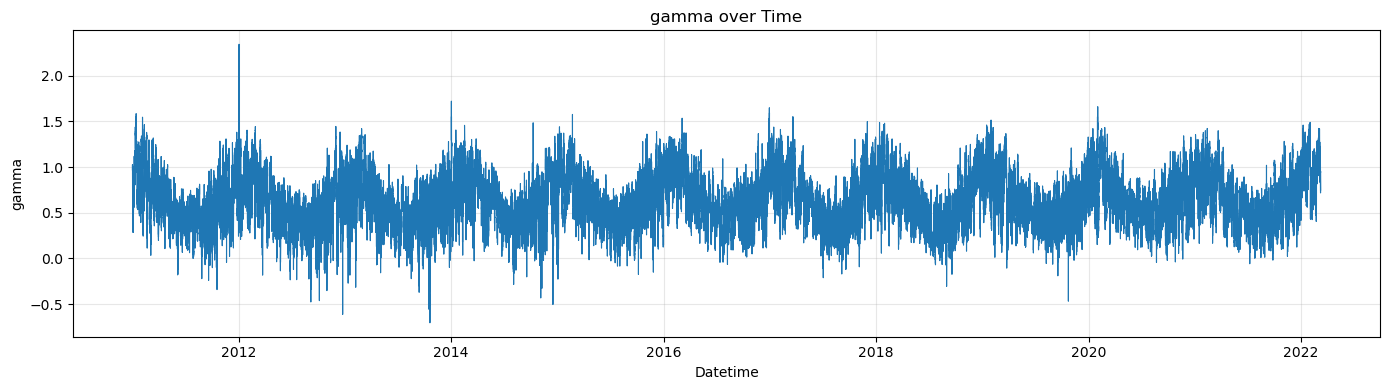

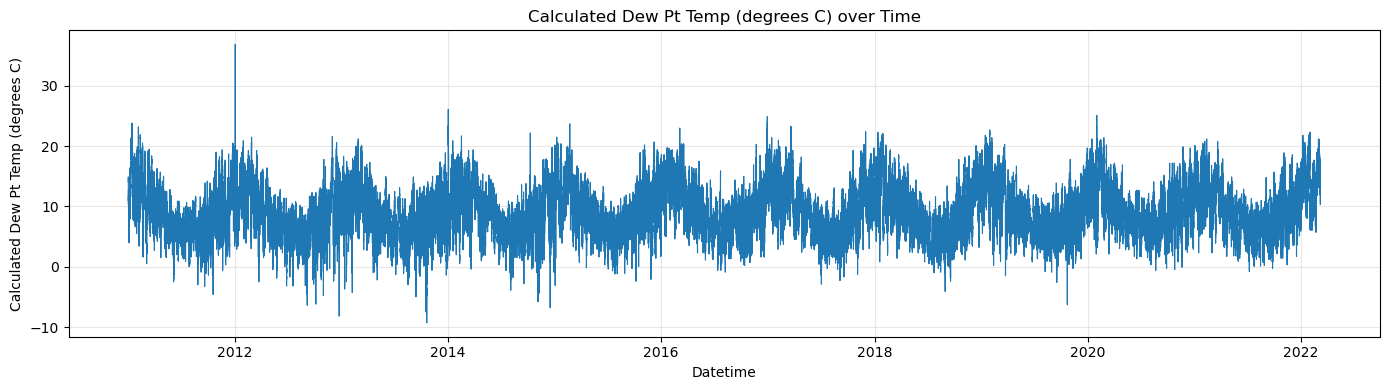

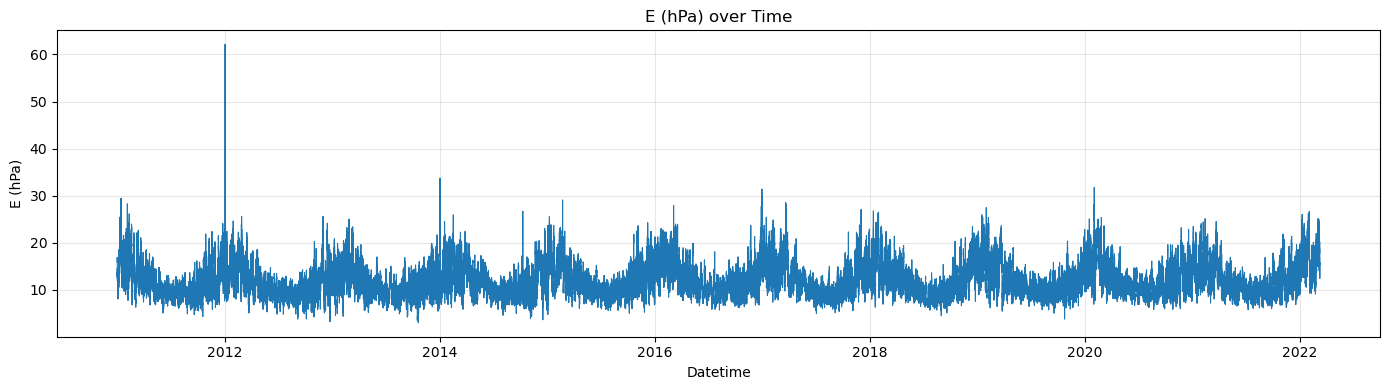

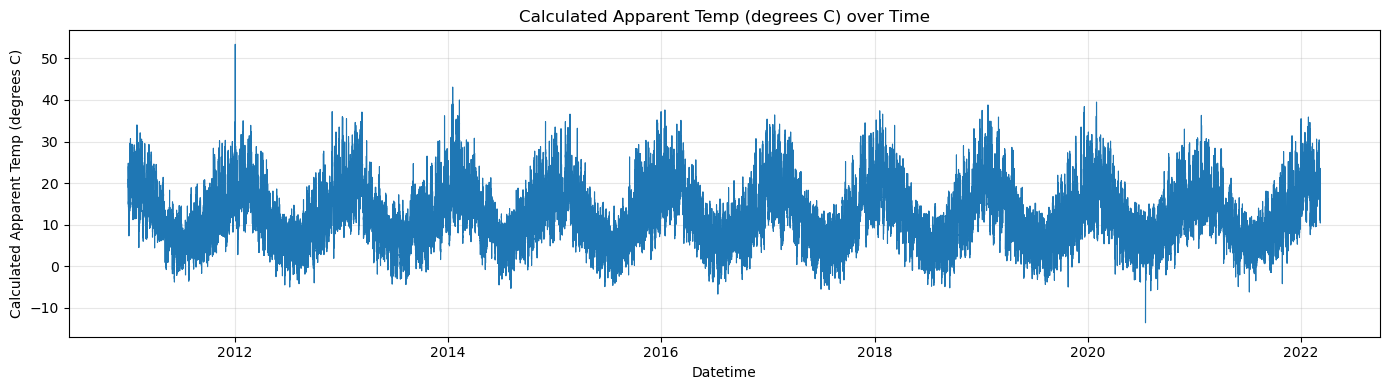

In [82]:
features = [
    'Air Temp (degrees C)',
    'Apparent Temp (degrees C)',
    'Dew Pt Temp (degrees C)',
    'Humidity (%)',
    'Wind Speed (km/h)',
    'Wind Gust  (km/h)',
    'MSLP (hPa)',
    'Rainfall since 9 am (mm)',
    'gamma',
    'Calculated Dew Pt Temp (degrees C)',
    'E (hPa)',
    'Calculated Apparent Temp (degrees C)'
]

# Loop through each feature and plot
for col in features:
    plt.figure(figsize=(14, 4))
    plt.plot(mel_data['Datetime'], mel_data[col], linewidth=0.8)
    plt.title(f'{col} over Time')
    plt.xlabel('Datetime')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [83]:
impossible_values = ([
    # Temperature
    (mel_data['Air Temp (degrees C)'] < -15) | (mel_data['Air Temp (degrees C)'] > 55), 

    # Apparent Temperature
    (mel_data['Apparent Temp (degrees C)'] < -20) | (mel_data['Apparent Temp (degrees C)'] > 60), 

    # Dew Point
    (mel_data['Dew Pt Temp (degrees C)'] < -20) | (mel_data['Dew Pt Temp (degrees C)'] > 40), 

    (mel_data['Calculated Dew Pt Temp (degrees C)'] > mel_data['Air Temp (degrees C)']), 

    # Humidity
    (mel_data['Humidity (%)'] < 0) | (mel_data['Humidity (%)'] > 100),

    # Wind Speed
    (mel_data['Wind Speed (km/h)'] < 0) | (mel_data['Wind Speed (km/h)'] > 180),

    # Wind Gust
    (mel_data['Wind Gust  (km/h)'] < 0) | (mel_data['Wind Gust  (km/h)'] > 220),

    # Pressure
    (mel_data['MSLP (hPa)'] < 940) | (mel_data['MSLP (hPa)'] > 1060),   

    # Rainfall
    (mel_data['Rainfall since 9 am (mm)'] < 0) | (mel_data['Rainfall since 9 am (mm)'] > 200),

    # Vapour pressure E
    (mel_data['E (hPa)'] < 0) | (mel_data['E (hPa)'] > 30),

    # gamma (dimensionless)
    (mel_data['gamma'] < -0.5) | (mel_data['gamma'] > 1.5)
]
)

for case in impossible_values:
    print(f"Impossible values count for {case.name}: {case.sum()}")

Impossible values count for Air Temp (degrees C): 0
Impossible values count for Apparent Temp (degrees C): 0
Impossible values count for Dew Pt Temp (degrees C): 0
Impossible values count for None: 0
Impossible values count for Humidity (%): 0
Impossible values count for Wind Speed (km/h): 0
Impossible values count for Wind Gust  (km/h): 1
Impossible values count for MSLP (hPa): 21
Impossible values count for Rainfall since 9 am (mm): 0
Impossible values count for E (hPa): 48
Impossible values count for gamma: 208


In [84]:
for case in impossible_values:
    mel_data = mel_data[~case] # Remove rows with impossible values, except for gamma which is derived from other columns
mel_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 504213 entries, 0 to 505354
Data columns (total 19 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   Year                                  504213 non-null  int64         
 1   Month                                 504213 non-null  int64         
 2   Day                                   504213 non-null  float64       
 3   Hour                                  504213 non-null  float64       
 4   Minute                                504213 non-null  float64       
 5   Air Temp (degrees C)                  504213 non-null  float64       
 6   Apparent Temp (degrees C)             504213 non-null  float64       
 7   Dew Pt Temp (degrees C)               504213 non-null  float64       
 8   Humidity (%)                          504213 non-null  float64       
 9   Wind Direction                        504213 non-null  object   

/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_5575/808262445.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mel_data = mel_data[~case] # Remove rows with impossible values, except for gamma which is derived from other columns
/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_5575/808262445.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mel_data = mel_data[~case] # Remove rows with impossible values, except for gamma which is derived from other columns
/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_5575/808262445.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mel_data = mel_data[~case] # Remove rows with impossible values, except for gamma which is derived from other columns
/var/folders/q0/1kjs8s8d6fn65050zv_j1x7c0000gn/T/ipykernel_5575/808262445.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  mel_data = mel

In [89]:
dummies=pd.get_dummies(mel_data['Wind Direction'], prefix='WindDir')
mel_data_clean = mel_data.join(dummies).drop(columns=['Wind Direction'])
wind_cols = [c for c in mel_data_clean.columns if c.startswith('WindDir_')]

daily_data = mel_data_clean.resample('D', on='Datetime').agg({
    **{col: 'mean' for col in wind_cols},
    'Air Temp (degrees C)': 'mean',
    'Humidity (%)': 'mean',
    'MSLP (hPa)': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Wind Gust  (km/h)': 'max',
    'E (hPa)': 'mean',
    'Dew Pt Temp (degrees C)': 'mean',
    'Apparent Temp (degrees C)': 'mean',
    'Rainfall since 9 am (mm)': 'last' 
})

monthly_data = daily_data.resample('ME').agg({
    **{col: 'mean' for col in wind_cols},
    'Air Temp (degrees C)': 'mean',
    'Humidity (%)': 'mean',
    'MSLP (hPa)': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Wind Gust  (km/h)': 'max',
    'E (hPa)': 'mean',
    'Dew Pt Temp (degrees C)': 'mean',
    'Apparent Temp (degrees C)': 'mean',
    'Rainfall since 9 am (mm)': 'last'
})

daily_data['RainTomorrow'] = (daily_data['Rainfall since 9 am (mm)'].shift(-1) > 0)
monthly_data['RainTomorrow'] = (monthly_data['Rainfall since 9 am (mm)'].shift(-1) > 0)

In [93]:
daily_data

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,Air Temp (degrees C),Humidity (%),MSLP (hPa),Wind Speed (km/h),Wind Gust (km/h),E (hPa),Dew Pt Temp (degrees C),Apparent Temp (degrees C),Rainfall since 9 am (mm),RainTomorrow
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01,0.00,0.000,0.038760,0.015504,0.007752,0.015504,0.007752,0.000000,0.023256,0.418605,...,19.651938,61.635659,1011.784496,14.325581,43.0,13.980619,12.004651,0.000000,0.0,False
2011-01-02,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.632653,...,18.169388,52.153061,1016.310204,21.775510,39.0,10.760363,8.087755,0.000000,0.0,False
2011-01-03,0.00,0.000,0.000000,0.007692,0.000000,0.000000,0.000000,0.000000,0.000000,0.446154,...,16.583846,47.807692,1016.946154,24.469231,41.0,8.949827,5.462308,0.000000,0.0,False
2011-01-04,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007752,0.000000,0.255814,...,16.780620,60.007752,1012.396899,15.697674,37.0,11.376651,8.866667,0.000000,0.0,False
2011-01-05,0.00,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,18.110853,66.565891,1010.086047,19.837209,37.0,13.699222,11.719380,0.000000,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-04,0.12,0.032,0.016000,0.016000,0.272000,0.024000,0.048000,0.064000,0.072000,0.056000,...,24.486400,66.512000,1009.955200,15.688000,46.0,19.023386,16.672800,25.424800,3.8,True
2022-03-05,0.00,0.000,0.015038,0.000000,0.007519,0.022556,0.000000,0.000000,0.007519,0.195489,...,19.320301,89.759398,1007.534586,19.406015,43.0,20.054762,17.533835,20.012030,1.2,False
2022-03-06,0.00,0.000,0.000000,0.000000,0.007692,0.000000,0.000000,0.000000,0.000000,0.000000,...,18.484615,79.061538,1015.901538,27.607692,57.0,16.734805,14.642308,17.083077,0.0,True


In [91]:
monthly_data

,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,Air Temp (degrees C),Humidity (%),MSLP (hPa),Wind Speed (km/h),Wind Gust (km/h),E (hPa),Dew Pt Temp (degrees C),Apparent Temp (degrees C),Rainfall since 9 am (mm),RainTomorrow
Datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-31,0.000000,0.020128,0.021912,0.008315,0.148876,0.013831,0.043647,0.023550,0.018345,0.219296,...,21.329569,63.923965,1011.091662,17.376138,63.0,16.103096,13.726874,0.000000,0.0,True
2011-02-28,0.000000,0.014318,0.010052,0.019973,0.153339,0.008993,0.024521,0.035315,0.028929,0.225363,...,20.131891,66.923866,1015.322475,15.996558,65.0,15.807624,13.427769,0.000000,0.2,False
2011-03-31,0.000000,0.003859,0.008059,0.007552,0.214548,0.011658,0.035690,0.032664,0.016599,0.186114,...,18.590570,63.404960,1016.397987,17.406933,72.0,13.530875,11.089426,0.000000,0.0,False
2011-04-30,0.000000,0.002018,0.005510,0.005127,0.314456,0.012532,0.043780,0.056959,0.047864,0.082070,...,16.066453,67.562713,1021.691691,16.909690,56.0,11.993817,9.605970,0.000000,0.0,False
2011-05-31,0.000000,0.007124,0.008671,0.007117,0.220224,0.008187,0.016324,0.023209,0.033421,0.091370,...,12.537956,71.337972,1020.364725,16.190946,67.0,10.282831,7.260676,0.000000,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-11-30,0.013927,0.004371,0.005369,0.003842,0.118461,0.021135,0.096984,0.011461,0.016040,0.198818,...,15.920753,68.212156,1014.388277,18.978151,82.0,12.103072,9.445688,13.882549,0.0,False
2021-12-31,0.015853,0.003193,0.003257,0.009866,0.118611,0.013222,0.065354,0.014728,0.022447,0.262996,...,18.314111,62.261597,1014.758960,19.394798,80.0,12.712270,10.336332,16.425705,0.0,False
2022-01-31,0.022045,0.012046,0.015343,0.016032,0.104467,0.033610,0.100610,0.017596,0.028393,0.202641,...,22.926297,64.413994,1012.404661,17.581054,65.0,17.440171,15.159417,22.935160,0.0,False


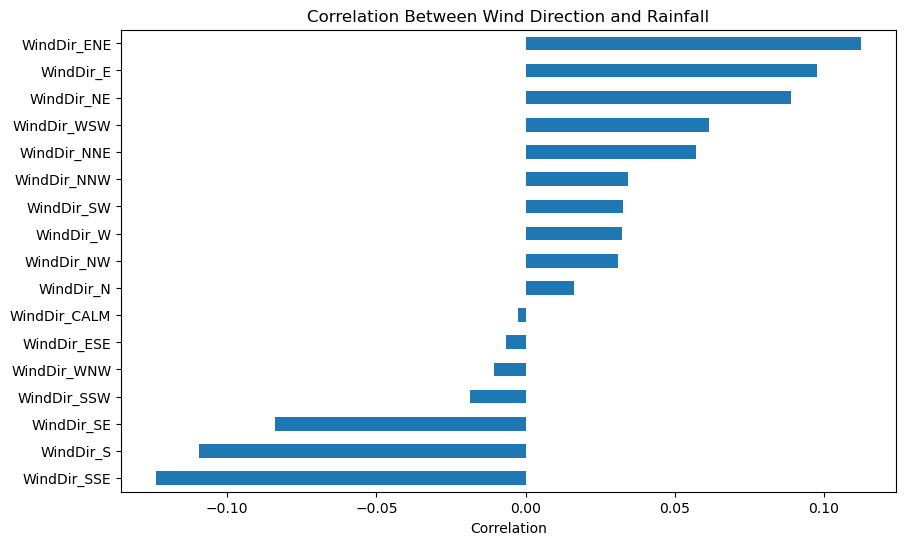

In [88]:
wind_cols = [c for c in daily_data.columns if c.startswith('WindDir_')]

corrs = daily_data[wind_cols + ['Rainfall since 9 am (mm)']].corr()['Rainfall since 9 am (mm)']

plt.figure(figsize=(10,6))
corrs[:-1].sort_values().plot(kind='barh')
plt.title('Correlation Between Wind Direction and Rainfall')
plt.xlabel('Correlation')
plt.show()

In [97]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)

X_train = daily_data.drop(columns=['RainTomorrow'])
y_train = daily_data['RainTomorrow']

X_test = daily_data.drop(columns=['RainTomorrow'])
y_test = daily_data['RainTomorrow']

In [99]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

tscv = TimeSeriesSplit(n_splits=5)

rf_2 = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=rf_2,
    param_grid=param_grid,
    cv=tscv,          # ← using TimeSeriesSplit here
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 400}


In [100]:
y_pred_2 = best_rf.predict(X_test)
y_prob_2 = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_2))
print("Precision:", precision_score(y_test, y_pred_2))
print("Recall:", recall_score(y_test, y_pred_2))
print("F1:", f1_score(y_test, y_pred_2))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_2))
print("PR-AUC:", average_precision_score(y_test, y_prob_2))

Accuracy: 0.8580171358629131
Precision: 0.733468286099865
Recall: 0.8545597484276729
F1: 0.7893972403776325
ROC-AUC: 0.9407913785278144
PR-AUC: 0.8852797362503618
